<a href="https://colab.research.google.com/github/Ellieh013/CN/blob/main/CNS_Lab1_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 1: Membrane Dynamics

**Course:** Computational Neuroscience  
**Duration:** 2 hours  
**Prerequisites:** Lab 0 (Differential Equations and Dynamical Systems)

---

## Learning Objectives

By the completion of this laboratory, you will be able to:

1. Implement and analyze the **passive membrane potential** model
2. Understand how **time constants** and **external inputs** determine membrane dynamics
3. Explore **active membrane dynamics** with voltage-gated conductances
4. Investigate mechanisms of **action potential** generation

---

## Introduction

Neurons are the fundamental processing units of the brain, communicating via electrical signals called action potentials (spikes). The membrane voltage of a neuron changes over time due to the flow of ions across the cell membrane. When this voltage reaches a threshold, an action potential is generated and transmitted to other neurons.

This laboratory explores two complementary models of membrane potential dynamics:
- **Passive dynamics**: constant conductances, describes subthreshold voltage changes
- **Active dynamics**: time/voltage-dependent conductances, explains action potential generation

Both models are formulated as differential equations that you will solve numerically using techniques from Lab 0.

</br>

<p align="center" width="100%">
<img src="https://drive.google.com/uc?id=115dpQEQ6qDvbW3lsDx5_p7t7BCJ1InWY"
width="1000px;">
</p>

*Figure 1: **A** Structure of a neuron with schematic of the action potential. **B** Membrane potential dynamics showing voltage fluctuations and spike generation when threshold is reached.*

---

## Note to Students
This lab builds directly on Lab 0. You will apply the Euler method to neuroscience-relevant differential equations modeling single neuron dynamics.

---

## Section 1: Passive Membrane Dynamics

### 1.1 The Passive Membrane Equation

The passive membrane potential evolves according to:

$$\tau \frac{dV}{dt} = -(V-E_m) + \frac{I_{ext}}{g_m}$$

where:
- $V(t)$ = membrane potential (mV)
- $\tau$ = membrane time constant (ms)
- $E_m$ = resting potential (mV)
- $I_{ext}$ = external input current
- $g_m$ = membrane conductance

This equation describes how the membrane voltage changes in response to external current input, with dynamics characterized by the time constant $\tau$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Optional: styling
import seaborn as sns

sns.set_theme(style="ticks", palette="colorblind")

### Exercise 1.1: Implement Euler Method for Passive Dynamics

**Objective:** Implement the Euler method to solve the passive membrane equation.

**Task:** Complete the function `euler_passive(t_span, dt, V0, tau, E_m, I_ext, g_m)` that:
- Takes simulation parameters and model parameters as input
- Returns arrays `t` (time points) and `V` (membrane potential)
- Uses the Euler update: $V_{n+1} = V_n + dt \cdot \frac{dV}{dt}\big|_{V_n}$

**Parameters:**
- `t_span = (0, 1000)` (ms) - simulate for 1 second
- `dt = 0.1` (ms)
- `V0 = -70` (mV) - initial condition
- `tau = 10` (ms), `E_m = -70` (mV), `g_m = 1`, `I_ext = 20`

Plot $V(t)$ over time.

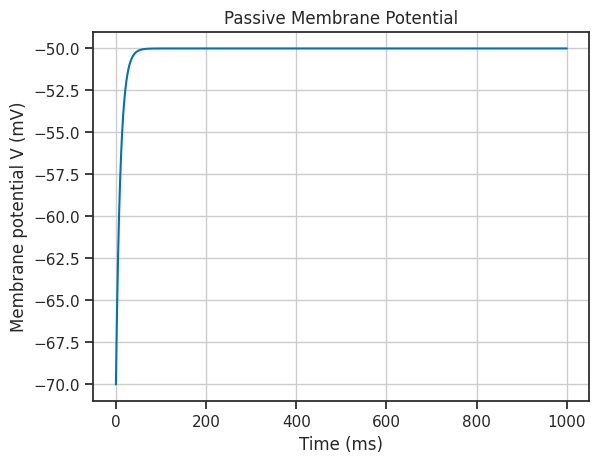

In [6]:
def euler_passive(t_span, dt, V0, tau, E_m, I_ext, g_m):
    """
    Solve passive membrane equation using Euler's method.

    Parameters:
    -----------
    t_span : tuple (t_start, t_end)
        Time interval for simulation
    dt : float
        Time step (ms)
    V0 : float
        Initial membrane potential (mV)
    tau : float
        Membrane time constant (ms)
    E_m : float
        Resting potential (mV)
    I_ext : float
        External input current
    g_m : float
        Membrane conductance

    Returns:
    --------
    t : ndarray
        Time points
    V : ndarray
        Membrane potential values
    """
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)

    # Create array for membrane potential
    V = np.zeros(len(t))

    # Initial condition
    V[0] = V0

    # Euler method
    for n in range(len(t) - 1):
        dVdt = (-(V[n] - E_m) + I_ext / g_m) / tau
        V[n + 1] = V[n] + dt * dVdt


    return t, V


# Simulation parameters
t_span = (0, 1000)
dt = 0.1
V0 = -70

# Model parameters
tau = 10
E_m = -70
g_m = 1
I_ext = 20

t, V = euler_passive(t_span, dt, V0, tau, E_m, I_ext, g_m)

# Plot
plt.plot(t, V)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Passive Membrane Potential")
plt.grid()
plt.show()

---

### Exercise 1.2: Analytical Solution

The passive membrane equation has an analytical solution (derived using integrating factors, similar to Lab 0):

$$V(t) = E_m + \frac{I_{ext}}{g_m} + \left(V_0 - E_m - \frac{I_{ext}}{g_m}\right)e^{-t/\tau}$$

**Objective:** Compare your numerical solution to the analytical solution.

**Task:**
1. Implement the analytical solution as a function `analytical_passive(t, V0, tau, E_m, I_ext, g_m)`
2. Plot both solutions on the same graph
3. Observe the agreement between the Euler method and analytical solution

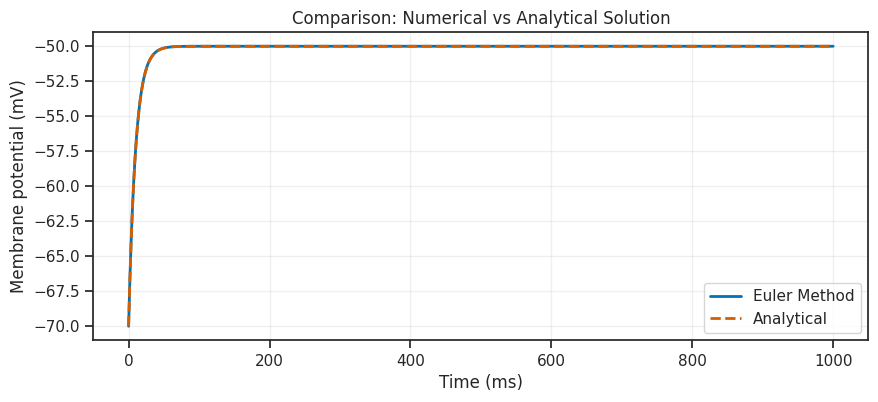

In [7]:
def analytical_passive(t, V0, tau, E_m, I_ext, g_m):
    """
    Analytical solution to passive membrane equation.

    Parameters:
    -----------
    t : ndarray
        Time points
    V0, tau, E_m, I_ext, g_m : float
        Model parameters (same as euler_passive)

    Returns:
    --------
    V : ndarray
        Analytical membrane potential values
    """
    V = (E_m + I_ext / g_m
         + (V0 - E_m - I_ext / g_m) * np.exp(-t / tau))



    return V


# Euler solution
t, V_euler = euler_passive(
    t_span, dt, V0, tau, E_m, I_ext, g_m
)

# Analytical solution
V_analytical = analytical_passive(
    t, V0, tau, E_m, I_ext, g_m
)

# TODO: Plot numerical vs analytical
plt.figure(figsize=(10, 4))
plt.plot(t, V_euler, "b-", linewidth=2, label="Euler Method")
plt.plot(t, V_analytical, "r--", linewidth=2, label="Analytical")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Comparison: Numerical vs Analytical Solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### Exercise 1.3: Parameter Exploration

**Objective:** Investigate how model parameters affect membrane dynamics.

**Task:** Using your Euler solver, explore how changing each parameter affects $V(t)$:

1. **External current**: Simulate for `I_ext = [-20, 0, 10, 20, 40]`, plot all curves on one graph
2. **Time constant**: Simulate for `tau = [1, 5, 10, 20, 50]`, plot all curves on one graph
3. **Initial condition**: Simulate for `V0 = [-80, -70, -60, -50, -40]`, plot all curves on one graph

Keep all other parameters at their default values. Use different colors for each curve and include a legend.

**Questions:**
- Which parameters affect the steady-state voltage?
- Which parameters affect how quickly steady-state is reached?

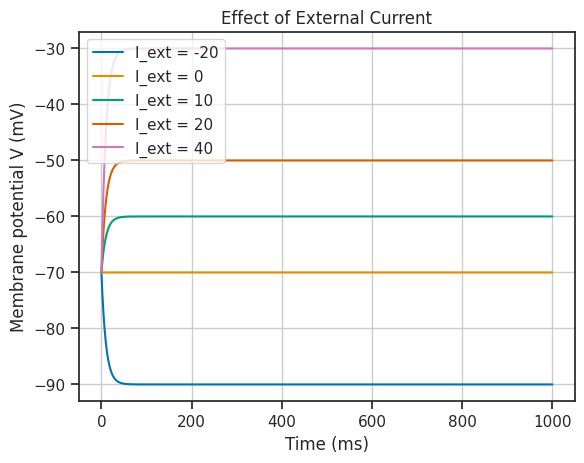

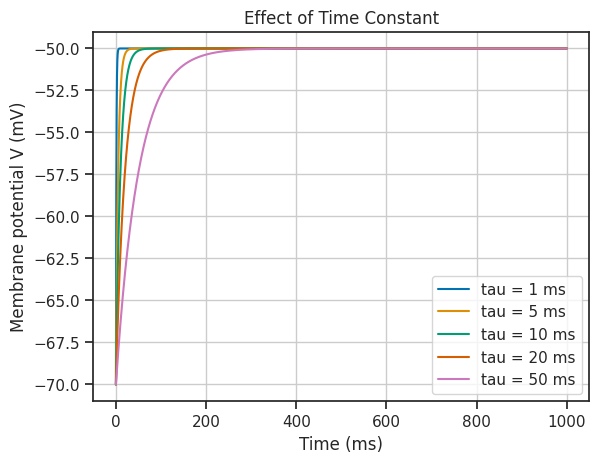

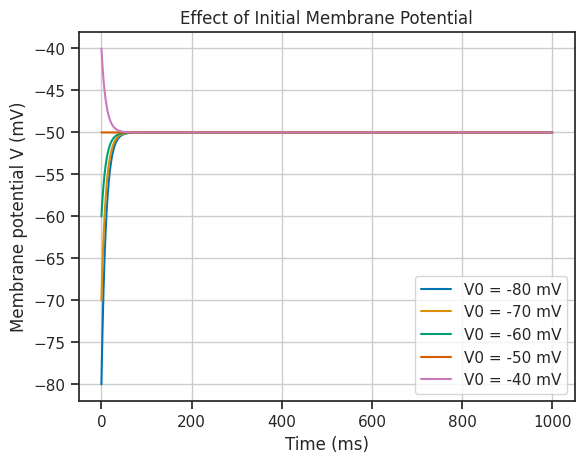

In [8]:
# Default parameters
t_span = (0, 1000)
dt = 0.1
V0 = -70
tau = 10
E_m = -70
g_m = 1

I_values = [-20, 0, 10, 20, 40]

plt.figure()

for I_ext in I_values:
    t, V = euler_passive(
        t_span, dt, V0, tau, E_m, I_ext, g_m
    )
    plt.plot(t, V, label=f"I_ext = {I_ext}")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of External Current")
plt.legend()
plt.grid()
plt.show()

tau_values = [1, 5, 10, 20, 50]

plt.figure()

for tau in tau_values:
    t, V = euler_passive(
        t_span, dt, V0, tau, E_m, I_ext=20, g_m=g_m
    )
    plt.plot(t, V, label=f"tau = {tau} ms")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Time Constant")
plt.legend()
plt.grid()
plt.show()

V0_values = [-80, -70, -60, -50, -40]

plt.figure()

for V0 in V0_values:
    t, V = euler_passive(
        t_span, dt, V0, tau=10, E_m=E_m, I_ext=20, g_m=g_m
    )
    plt.plot(t, V, label=f"V0 = {V0} mV")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Initial Membrane Potential")
plt.legend()
plt.grid()
plt.show()

---

### Exercise 1.4: Steady-State Analysis

When the membrane potential stops changing ($dV/dt = 0$), the system has reached **steady state**.

**Objective:** Derive and verify the steady-state voltage formula.

**Task:**
1. Set $dV/dt = 0$ in the passive membrane equation and solve for $V_\infty$
2. Write a function `steady_state_passive(E_m, I_ext, g_m)` that returns $V_\infty$
3. Verify numerically: simulate until steady state is reached and compare the final voltage to your formula

**Question:** Does $V_\infty$ depend on $\tau$ or $V_0$? Why or why not?

In [9]:
def steady_state_passive(E_m, I_ext, g_m):
    """
    Analytical steady-state voltage for passive membrane.

    Parameters:
    -----------
    E_m, I_ext, g_m : float
        Model parameters

    Returns:
    --------
    V_inf : float
        Steady-state membrane potential
    """
    V_inf = E_m + I_ext / g_m

    return V_inf


E_m = -70
I_ext = 20
g_m = 1

V_inf = steady_state_passive(E_m, I_ext, g_m)

print("Steady-state voltage:", V_inf, "mV")

# Parameters
t_span = (0, 1000)
dt = 0.1
V0 = -70
tau = 10
E_m = -70
I_ext = 20
g_m = 1

# Numerical solution
t, V = euler_passive(
    t_span, dt, V0, tau, E_m, I_ext, g_m
)

# Analytical steady state
V_inf = steady_state_passive(E_m, I_ext, g_m)

# Compare
print("Formula steady state:", V_inf, "mV")
print("Final Euler voltage:", V[-1], "mV")
print("Difference:", abs(V[-1] - V_inf), "mV")

Steady-state voltage: -50.0 mV
Formula steady state: -50.0 mV
Final Euler voltage: -50.000000000000355 mV
Difference: 3.552713678800501e-13 mV


---

## Section 2: Active Membrane Dynamics

### 2.1 Multiple Ion Channels

Real neurons have multiple types of ion channels with different conductances and reversal potentials:

$$C_m \frac{dV}{dt} = -g_L(V-E_L) - g_K(V-E_K) - g_{Na}(V-E_{Na}) + I_{ext}$$

where:
- $C_m$ = membrane capacitance
- $g_L, g_K, g_{Na}$ = leak, potassium, sodium conductances
- $E_L, E_K, E_{Na}$ = corresponding reversal potentials

Each term $-g_i(V - E_i)$ represents current through a different ion channel. This generalizes the passive model to multiple conductances.

### Exercise 2.1: Implement Active Membrane Dynamics

**Objective:** Extend your Euler solver to handle multiple conductances.

**Task:** Implement `euler_active(t_span, dt, V0, C_m, g_L, E_L, g_K, E_K, g_Na, E_Na, I_ext)` that solves the active membrane equation.

**Default parameters:**
- `t_span = (0, 50)`, `dt = 0.1`, `V0 = -70`
- `C_m = 12`, `I_ext = 0`
- `g_L = 1`, `E_L = -70`
- `g_K = 0.2`, `E_K = -80`
- `g_Na = 0`, `E_Na = 50`

Simulate and plot $V(t)$.

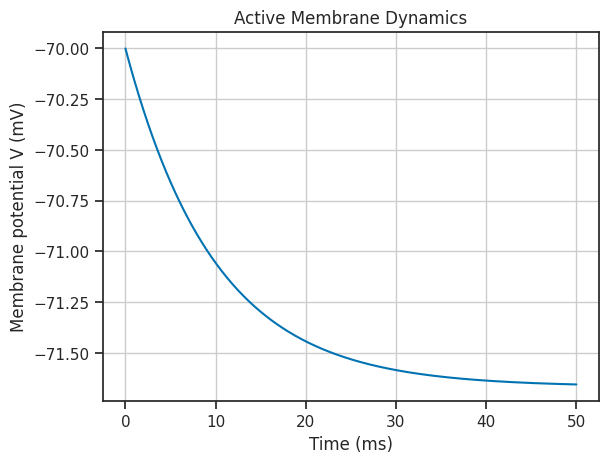

In [11]:
def euler_active(t_span, dt, V0, C_m, g_L, E_L, g_K, E_K, g_Na, E_Na, I_ext):
    """
    Solve active membrane equation using Euler's method.

    Parameters:
    -----------
    t_span : tuple (t_start, t_end)
    dt : float
    V0 : float, initial membrane potential
    C_m : float, membrane capacitance
    g_L, g_K, g_Na : float, conductances
    E_L, E_K, E_Na : float, reversal potentials
    I_ext : float, external current

    Returns:
    --------
    t : ndarray, time points
    V : ndarray, membrane potential
    """
    t_start, t_end = t_span


    # Create time points
    t = np.arange(t_start, t_end + dt, dt)

    # Create array for membrane potential
    V = np.zeros(len(t))

    # Initial condition
    V[0] = V0

    # Euler method
    for n in range(len(t) - 1):

        dVdt = (
            -g_L * (V[n] - E_L)
            -g_K * (V[n] - E_K)
            -g_Na * (V[n] - E_Na)
            + I_ext
        ) / C_m

        V[n + 1] = V[n] + dt * dVdt

    return t, V


# Simulation parameters
t_span = (0, 50)
dt = 0.1
V0 = -70

# Model parameters
C_m = 12
I_ext = 0

g_L = 1
E_L = -70

g_K = 0.2
E_K = -80

g_Na = 0
E_Na = 50

# Solve using Euler's method
t, V = euler_active(
    t_span, dt, V0, C_m,
    g_L, E_L,
    g_K, E_K,
    g_Na, E_Na,
    I_ext
)

# Plot
plt.plot(t, V)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Active Membrane Dynamics")
plt.grid()
plt.show()

---

### Exercise 2.2: Effect of Conductances and Reversal Potentials

**Objective:** Understand how individual ion channels influence membrane potential.

**Task:** Using the default parameters from Exercise 2.1, explore how each conductance affects $V(t)$:

1. **Leak conductance**: Vary `g_L = [0.5, 1, 2, 4]` (keep all others at default), plot $V(t)$ for each value
2. **Potassium conductance**: Vary `g_K = [0, 0.2, 0.5, 1.0]` (keep all others at default), plot $V(t)$ for each value
3. **Sodium conductance**: Vary `g_Na = [0, 0.1, 0.2, 0.5]` (keep all others at default), plot $V(t)$ for each value

Then explore how reversal potentials affect steady state:

4. **Leak reversal**: Vary `E_L = [-80, -70, -60, -50]` (keep all others at default), plot $V(t)$ for each value
5. **Potassium reversal**: Vary `E_K = [-100, -90, -80, -70]` (keep all others at default), plot $V(t)$ for each value
6. **Sodium reversal**: Vary `E_Na = [30, 40, 50, 60]` (Hint: another parameter must change), plot $V(t)$ for each value

**Questions:**
- How does each conductance affect steady-state voltage and dynamics?
- How does each reversal potential affect steady state?
- Can you predict the steady-state formula for the active model?

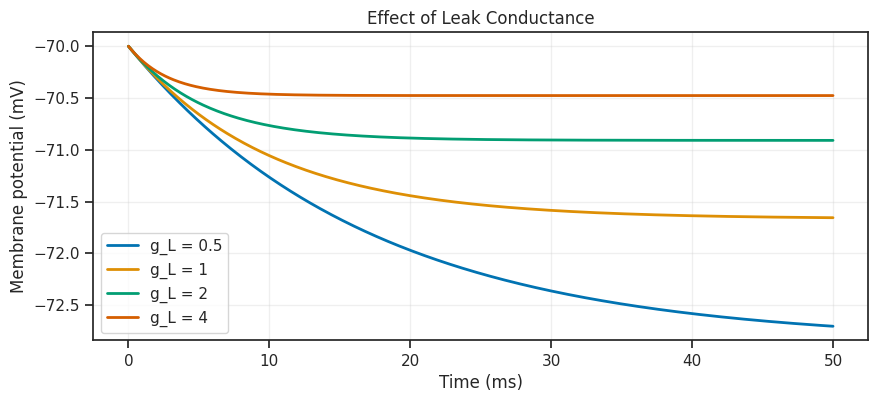

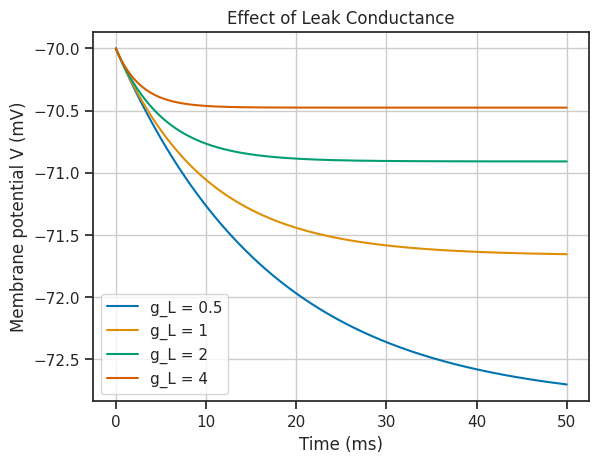

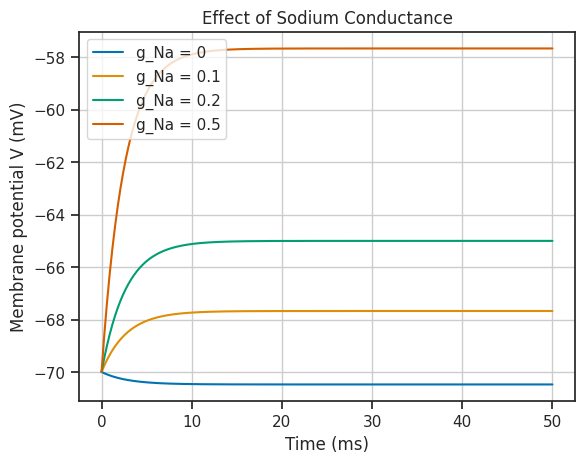

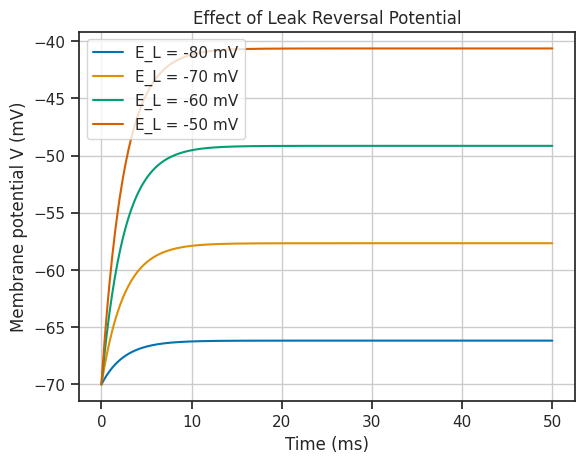

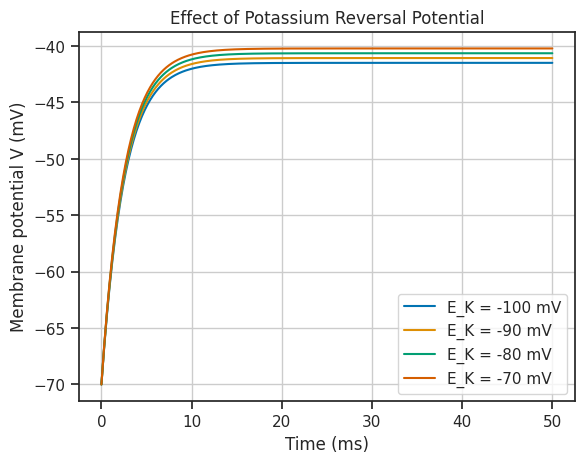

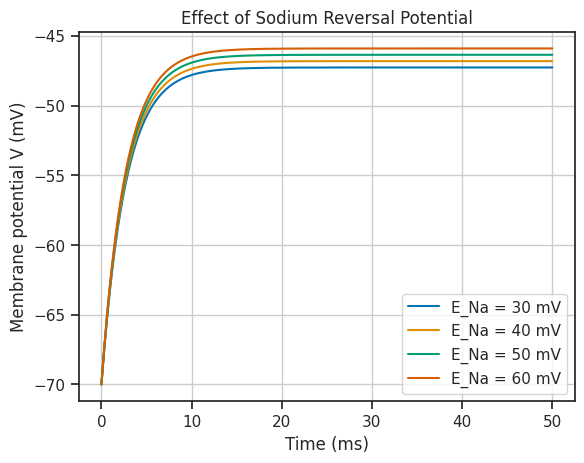

In [12]:
# Explore g_L (Example)
g_L_values = [0.5, 1, 2, 4]
plt.figure(figsize=(10, 4))
for g_L_var in g_L_values:
    t, V = euler_active(t_span, dt, V0, C_m, g_L_var, E_L, g_K, E_K, g_Na, E_Na, I_ext)
    plt.plot(t, V, linewidth=2, label=f"g_L = {g_L_var}")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Effect of Leak Conductance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

g_L_values = [0.5, 1, 2, 4]

plt.figure()

for g_L in g_L_values:
    t, V = euler_active(
        t_span, dt, V0, C_m,
        g_L, E_L,
        g_K, E_K,
        g_Na, E_Na,
        I_ext
    )
    plt.plot(t, V, label=f"g_L = {g_L}")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Leak Conductance")
plt.legend()
plt.grid()
plt.show()


g_Na_values = [0, 0.1, 0.2, 0.5]

plt.figure()

for g_Na in g_Na_values:
    t, V = euler_active(
        t_span, dt, V0, C_m,
        g_L, E_L,
        g_K, E_K,
        g_Na, E_Na,
        I_ext
    )
    plt.plot(t, V, label=f"g_Na = {g_Na}")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Sodium Conductance")
plt.legend()
plt.grid()
plt.show()


E_L_values = [-80, -70, -60, -50]

plt.figure()

for E_L in E_L_values:
    t, V = euler_active(
        t_span, dt, V0, C_m,
        g_L, E_L,
        g_K, E_K,
        g_Na, E_Na,
        I_ext
    )
    plt.plot(t, V, label=f"E_L = {E_L} mV")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Leak Reversal Potential")
plt.legend()
plt.grid()
plt.show()


E_K_values = [-100, -90, -80, -70]

plt.figure()

for E_K in E_K_values:
    t, V = euler_active(
        t_span, dt, V0, C_m,
        g_L, E_L,
        g_K, E_K,
        g_Na, E_Na,
        I_ext
    )
    plt.plot(t, V, label=f"E_K = {E_K} mV")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Potassium Reversal Potential")
plt.legend()
plt.grid()
plt.show()


g_Na = 0.2
E_Na_values = [30, 40, 50, 60]

plt.figure()

for E_Na in E_Na_values:
    t, V = euler_active(
        t_span, dt, V0, C_m,
        g_L, E_L,
        g_K, E_K,
        g_Na, E_Na,
        I_ext
    )
    plt.plot(t, V, label=f"E_Na = {E_Na} mV")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Effect of Sodium Reversal Potential")
plt.legend()
plt.grid()
plt.show()


---

### Exercise 2.3: Steady State with Multiple Conductances

**Objective:** Derive the steady-state voltage for multiple ion channels.

**Task:**
1. Set $dV/dt = 0$ in the active membrane equation
2. Solve for $V_\infty$ (it should be a weighted average of reversal potentials)
3. Verify your formula numerically

**Result:** You should find (when $I_{ext} = 0$):
$$V_\infty = \frac{g_L E_L + g_K E_K + g_{Na} E_{Na}}{g_L + g_K + g_{Na}}$$

In [14]:
def steady_state_active(g_L, E_L, g_K, E_K, g_Na, E_Na, I_ext, C_m):
    """
    Analytical steady-state voltage for active membrane.

    Returns:
    --------
    V_inf : float
        Steady-state membrane potential
    """
    V_inf = (
        g_L * E_L
        + g_K * E_K
        + g_Na * E_Na
        + I_ext
    ) / (g_L + g_K + g_Na)

    return V_inf


# Default parameters
t_span = (0, 50)
dt = 0.1
V0 = -70

C_m = 12
I_ext = 0

g_L = 1
E_L = -70

g_K = 0.2
E_K = -80

g_Na = 0
E_Na = 50

# Numerical solution
t, V = euler_active(
    t_span, dt, V0, C_m,
    g_L, E_L,
    g_K, E_K,
    g_Na, E_Na,
    I_ext
)

# Formula
V_inf = steady_state_active(
    g_L, E_L,
    g_K, E_K,
    g_Na, E_Na,
    I_ext, C_m
)

print("Steady-state formula:", V_inf, "mV")
print("Final Euler voltage:", V[-1], "mV")
print("Difference:", abs(V[-1] - V_inf), "mV")

Steady-state formula: -71.66666666666667 mV
Final Euler voltage: -71.655715861596 mV
Difference: 0.010950805070677916 mV


---

**Note on Time Constants:**

The effective time constant for the active model is:
$$\tau_{eff} = \frac{C_m}{g_L + g_K + g_{Na}}$$

Higher total conductance → faster dynamics (shorter time constant).

---

## Section 3: Action Potential Generation

### 3.1 Time-Dependent Conductances

So far, conductances have been constant. In reality, ion channels open and close in response to voltage changes, creating **time-dependent conductances** $g_{Na}(t)$ and $g_K(t)$.

We can gain intuition by manually controlling conductances in a "conductance clamp" experiment.

### Exercise 3.1: Sodium Conductance Pulse

**Objective:** Observe the effect of rapidly increasing sodium conductance.

**Task:** Modify your `euler_active` function to accept time-varying conductances:

1. Create arrays `g_Na_t` and `g_K_t` of appropriate length (number of time steps)
2. Set `g_Na = 0` for `t < 25` ms, `g_Na = 100` for `t >= 25` ms
3. Keep `g_K = 0.2` (constant)
4. Simulate and plot both $V(t)$ and conductances over time (use subplots)

**Question:** What happens to voltage when sodium conductance suddenly increases? Why?

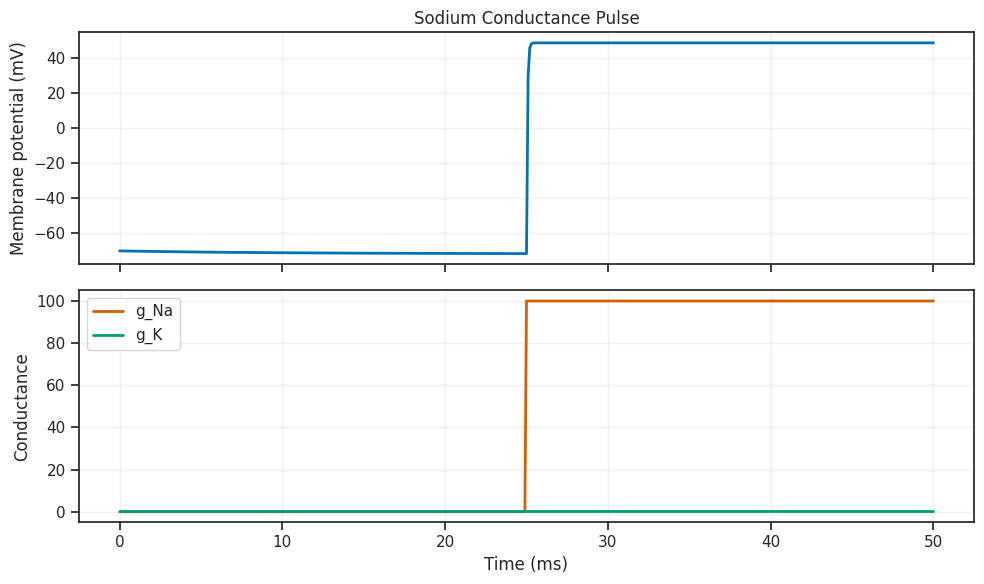

In [15]:
def euler_active_timevarying(
    t_span, dt, V0, C_m, g_L, E_L, g_K_t, E_K, g_Na_t, E_Na, I_ext
):
    """
    Solve active membrane equation with time-varying conductances.

    Parameters:
    -----------
    g_K_t, g_Na_t : ndarray
        Time-varying conductances (arrays of length N_t)
    Other parameters same as euler_active

    Returns:
    --------
    t : ndarray, time points
    V : ndarray, membrane potential
    """
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)

    V = np.zeros(len(t))
    V[0] = V0

    for n in range(len(t) - 1):

        dVdt = (
            -g_L * (V[n] - E_L)
            -g_K_t[n] * (V[n] - E_K)
            -g_Na_t[n] * (V[n] - E_Na)
            + I_ext
        ) / C_m

        V[n + 1] = V[n] + dt * dVdt

    return t, V


# Parameters
t_span = (0, 50)
dt = 0.1

# Create time-dependent conductance arrays
N_t = int((t_span[1] - t_span[0]) / dt) + 1
g_Na_t = np.zeros(N_t)
g_Na_t[250:] = 100  # t >= 25 ms (index 250 at dt=0.1)

g_K_t = np.ones(N_t) * 0.2  # Constant

# Time-varying simulation
t, V = euler_active_timevarying(
    t_span, dt, V0, C_m, g_L, E_L, g_K_t, E_K, g_Na_t, E_Na, I_ext
)

# Create 2-panel plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, V, "b-", linewidth=2)
ax1.set_ylabel("Membrane potential (mV)")
ax1.set_title("Sodium Conductance Pulse")
ax1.grid(True, alpha=0.3)

ax2.plot(t, g_Na_t, "r-", linewidth=2, label="g_Na")
ax2.plot(t, g_K_t, "g-", linewidth=2, label="g_K")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Conductance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### Exercise 3.2: Sodium-Potassium Sequence

**Objective:** Generate an action potential-like waveform.

**Task:** Create a conductance sequence that mimics an action potential:

1. `g_Na = 100` for `25 < t < 26` ms (sodium pulse)
2. `g_K = 100` for `26 < t < 27` ms (potassium pulse)
3. Baseline values otherwise (`g_Na = 0`, `g_K = 0.2`)
4. Plot $V(t)$, `g_Na(t)`, and `g_K(t)` on separate subplots

**Question:** How does this sequence generate an action potential shape? Compare to Figure 1B in the introduction.

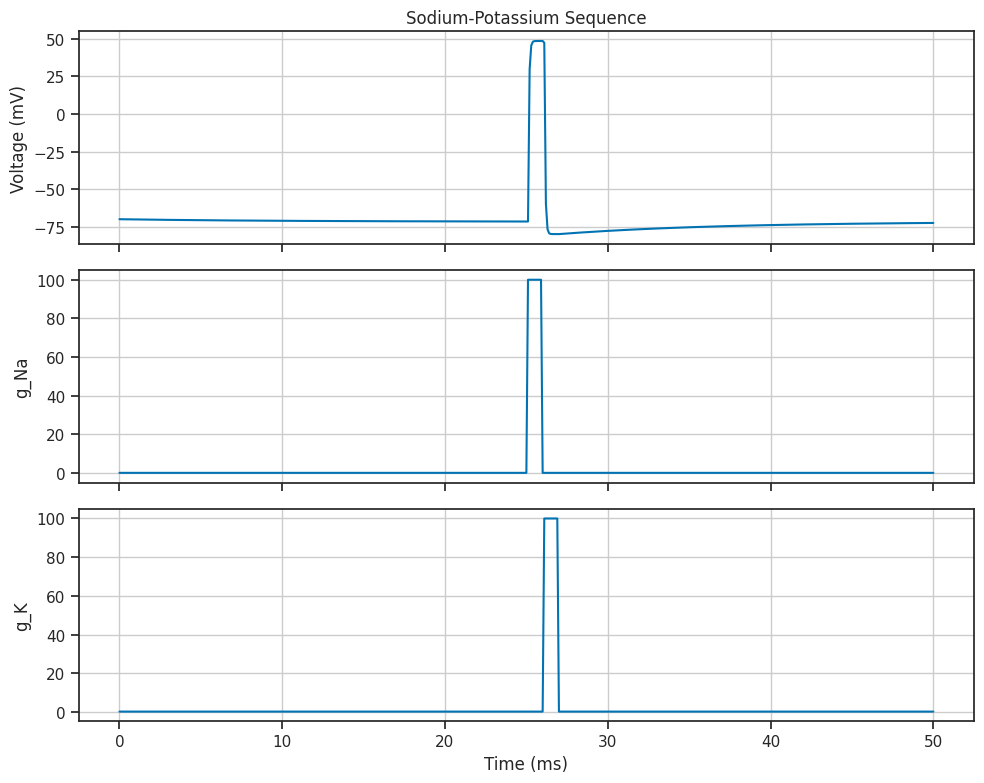

In [16]:
# TODO: Create conductance sequences
N_t = int((t_span[1] - t_span[0]) / dt) + 1

g_Na_t = np.zeros(N_t)
g_K_t = np.ones(N_t) * 0.2

# Sodium pulse: 25 < t < 26 ms
t_array = np.arange(t_span[0], t_span[1] + dt, dt)
g_Na_t[(t_array > 25) & (t_array < 26)] = 100

# Potassium pulse: 26 < t < 27 ms
g_K_t[(t_array > 26) & (t_array < 27)] = 100


# TODO: Simulate
t, V = euler_active_timevarying(
    t_span, dt, V0, C_m,
    g_L, E_L,
    g_K_t, E_K,
    g_Na_t, E_Na,
    I_ext
)


# TODO: Create 2-panel plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Voltage
ax1.plot(t, V)
ax1.set_ylabel("Voltage (mV)")
ax1.set_title("Sodium-Potassium Sequence")
ax1.grid(True)

# Sodium conductance
ax2.plot(t, g_Na_t, label="g_Na")
ax2.set_ylabel("g_Na")
ax2.grid(True)

# Potassium conductance
ax3.plot(t, g_K_t, label="g_K")
ax3.set_xlabel("Time (ms)")
ax3.set_ylabel("g_K")
ax3.grid(True)

plt.tight_layout()
plt.show()

---

### 3.3 Connection to the Hodgkin-Huxley Model

**Q**: The conductance clamp experiments demonstrate the key principle behind action potential generation. Think carefully about what happens in each step below and explain:

1. **Depolarization** →
2. **Repolarization** →
3. **Hyperpolarization** →

**Q:** Why is are the action potentials so fast?

**A:**

Note:
In the **Hodgkin-Huxley model** (Lecture 4), the conductances $g_{Na}(V,t)$ and $g_K(V,t)$ are governed by voltage-dependent differential equations, creating a self-sustaining action potential without manual control.

---

# Bonus Section: Derivation of the Nernst Equation (Optional)

In this section, we will carry out a simple derivation of the Nernst equation introduced in Lecture 3, starting from basic physical principles. This is not the only derivation of the Nernst equation, nor the most direct, but it is perhaps the simplest. The derivation invokes two principles that you may not be familiar with - first, the Boltzmann distribution from statistical physics (later adopted in machine learning), second, the energy required to move a charge along a voltage difference.

Consider a particle (e.g., an ion) of charge $q$ that can be in one of two states (e.g., inside or outside of a neuron). Assume that there is a voltage $V$ separating the two states - electrostatic theory tells us that takes $\Delta E=E_{out}-E_{in} = qV$ Joules of energy to move the particle against this voltage (i.e. to move an ion from inside to outside the neuron). The Boltzmann distribution tells us that, at thermal equilibrium, the probability that a closed system will be in state $i$ with energy $E_i$ is $p(E_i) \propto e^{-E_i/kT}$, where $T$ is the temperature of the system. We will assume that we have a closed system at thermal equilibrium, but this is of course not really the case in the brain. To derive the Nernst equation:

* Consider a system formed of just one ion, which can be either inside or outside a neuron, subject to the aforementioned voltage difference. Write down an expression for $p(E_{out})/p(E_{in})$, the ratio of the probability of the ion being outside vs inside the cell.
* Now assume that we have a system of many such ions, that they are all independent of each other, and each subject to the same voltage $V$. What is the ratio of their concentration outside vs inside $[out]/[in]$? (Hint: this is trivial given the result of the above question)
* Given this result, what voltage $V$ is required to maintain a given concentration ratio $[out]/[in]$, at a given temperature $T$?
* Compare your result to the Nernst equation given in lecture 3. Can you make the two equations equal? How does the Boltzmann factor $k$ relate to the two constants $R$ and $F$?

**A:**

---

## Appendix: Analytical Solution Derivation

The passive membrane equation can be solved using the integrating factor method from Lab 0.

Starting with:
$$\frac{dV}{dt} + \frac{V}{\tau} = \frac{1}{\tau}\left(E_m + \frac{I_{ext}}{g_m}\right)$$

Multiply both sides by the integrating factor $e^{t/\tau}$:
$$e^{t/\tau}\frac{dV}{dt} + e^{t/\tau}\frac{V}{\tau} = \frac{1}{\tau}e^{t/\tau}\left(E_m + \frac{I_{ext}}{g_m}\right)$$

The left side is the derivative of $Ve^{t/\tau}$:
$$\frac{d}{dt}\left(Ve^{t/\tau}\right) = \frac{1}{\tau}e^{t/\tau}\left(E_m + \frac{I_{ext}}{g_m}\right)$$

Integrate from $0$ to $t$:
$$V(t)e^{t/\tau} - V(0) = \left(E_m + \frac{I_{ext}}{g_m}\right)\left(e^{t/\tau} - 1\right)$$

Solve for $V(t)$:
$$V(t) = E_m + \frac{I_{ext}}{g_m} + \left(V_0 - E_m - \frac{I_{ext}}{g_m}\right)e^{-t/\tau}$$